In [1]:
# Cell 1A: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT / "figures" / "figures_GRWs" / "Naive" / "figures_Naive_GRW_Y_stab_pos"
RESULTS = PROJ_ROOT / "results" / "results_GRWs" / "Naive" / "results_Naive_GRW_Y_stab_pos"

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)


MODEL_NAME = 'Naïve-GRW-Y-Stab-Pos'
MODEL_TAG = 'naive_grw_y_stab_pos'

In [2]:
# Cell 1B: analysis settings

EPS = 0.49
N = 10000
Y = 20
SEED = 63

rng = np.random.default_rng(SEED)

stage_spans = [
    (0, 4,  "0.70", "0-4"),
    (5, 7,  "0.78", "5-7"),
    (8, 13, "0.86", "8-13"),
    (14, 20,"0.93", "14-20")]

In [3]:
# Cell 1C: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

print(df_original.shape)
df_original.head()


(54948, 21)


,contribs,contribs_with_corr,current,dblp,department,facultyName,first_asst_job_rank,first_asst_job_year,has_postdoc,is_female,...,phd_rank,phd_year,place,pubs,pubs_adj,pubs_with_corr,pubs_with_corr_adj,recordDate,year,CareerAge
0,0.342857,0.342857,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,2,3.902057,2,3.902057,6/6/11,1998,-3
1,0.250000,0.250000,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,1,1.875160,1,1.875160,6/6/11,1999,-2
2,1.833333,1.833333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,7.214900,4,7.214900,6/6/11,2000,-1
3,1.583333,1.583333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,3,5.209137,3,5.209137,6/6/11,2001,0
4,1.444444,1.444444,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,6.691238,4,6.691238,6/6/11,2002,1


In [4]:
# Cell 2A: build empirical panel

# build unique id
df_original['dblp_id'] = df_original['dblp'] + df_original['phd_year'].astype(str)
working_df = (df_original.sort_values(["dblp_id", "CareerAge"]).copy())

working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)


# These were to replicate the repo method of dropping zeros 
# working_df = working_df.loc[working_df['pubs_adj'] != 0].copy()
# working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"])


working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)

working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]

is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)

working_df_fit = (working_df[is_next_year & is_in_window].dropna(subset=["log_pubs_adj", "log_pubs_next"]).copy())

print("Rows in orig:", len(working_df))
print("Rows w/ ok 1yr trans:", len(working_df_fit))
print()
print(working_df_fit[["log_pubs_adj", "log_pubs_next", "log_delta"]].describe())

Rows in orig: 54948
Rows w/ ok 1yr trans: 34701

       log_pubs_adj  log_pubs_next     log_delta
count  34701.000000   34701.000000  34701.000000
mean       1.442084       1.448262      0.006178
std        1.131298       1.123265      1.057639
min       -0.713350      -0.713350     -5.028100
25%        0.924939       0.924939     -0.509761
50%        1.661082       1.661082     -0.026502
75%        2.251545       2.251545      0.523108
max        4.396630       4.396630      4.138016


In [5]:
# Cell 2B: career years

obs_years = np.arange(0, Y + 1)
transition_years = np.arange(0, Y)

print("Prod obs by career year:")
print(working_df.loc[working_df["CareerAge"].between(0, Y), "CareerAge"].value_counts().sort_index().reindex(obs_years))
print()
print("Trans obs by starting career year:")
print(working_df_fit["CareerAge"].value_counts().sort_index().reindex(transition_years))


Prod obs by career year:
CareerAge
0     2069
1     2149
2     2208
3     2252
4     2283
5     2277
6     2214
7     2156
8     2074
9     1992
10    1903
11    1823
12    1713
13    1609
14    1497
15    1373
16    1275
17    1178
18    1096
19    1028
20     957
Name: count, dtype: int64

Trans obs by starting career year:
CareerAge
0     2067
1     2143
2     2202
3     2247
4     2259
5     2200
6     2142
7     2059
8     1985
9     1895
10    1814
11    1710
12    1599
13    1493
14    1367
15    1271
16    1174
17    1094
18    1023
19     957
Name: count, dtype: int64


In [6]:
# Cell 3: log-prod params by career year

year_logprod_rows = []

for year in obs_years:
    subset = working_df[working_df["CareerAge"] == year]
    vals = subset["log_pubs_adj"].dropna()

    year_logprod_rows.append({
        "year": year,
        "n": len(vals),
        "mean_log_productivity": vals.mean(),
        "var_log_productivity": vals.var(ddof=0),
        "sd_log_productivity": vals.std(ddof=0)})

year_logprod_params = pd.DataFrame(year_logprod_rows)
year_logprod_params


,year,n,mean_log_productivity,var_log_productivity,sd_log_productivity
0,0,2069,1.096164,1.169240,1.081314
1,1,2149,1.143948,1.206474,1.098396
2,2,2208,1.420733,1.146156,1.070587
3,3,2252,1.597963,1.111421,1.054239
4,4,2283,1.649832,1.152084,1.073352
5,5,2277,1.685266,1.157075,1.075674
6,6,2214,1.630428,1.173957,1.083493
7,7,2156,1.587435,1.151704,1.073175
8,8,2074,1.510005,1.208534,1.099334
9,9,1992,1.494018,1.177235,1.085005


In [7]:
# Cell 4: fit global, yearwise naive log-delta models

def fit_stab_log_delta(subset):
    tmp = subset[["log_pubs_adj", "log_delta"]].replace([np.inf, -np.inf], np.nan).dropna()

    x = tmp["log_pubs_adj"].to_numpy()
    y = tmp["log_delta"].to_numpy()

    if len(tmp) < 3 or np.var(x) == 0:
        beta = 0
        intercept = y.mean()
        resid = y - intercept
    else:
        beta, intercept = np.polyfit(x, y, 1)
        resid = y - (intercept + beta*x)

    return {
        "n": len(tmp),
        "intercept_log_delta": intercept,
        "beta_log_prod": beta,
        "sigma_log_delta": resid.std(ddof=0),
        "mean_log_delta": y.mean(),
        "sample_sd_log_delta": y.std(ddof=0)}


global_delta_params = pd.DataFrame([{"model": "global", **fit_stab_log_delta(working_df_fit)}])

year_delta_rows = []

for year in transition_years:
    subset = working_df_fit[working_df_fit["CareerAge"] == year].copy()
    year_delta_rows.append({"year": year, **fit_stab_log_delta(subset)})

year_delta_params = pd.DataFrame(year_delta_rows)

print("Global log-delta")
display(global_delta_params)

print("Yearwise log-delta")
display(year_delta_params)


Global log-delta


,model,n,intercept_log_delta,beta_log_prod,sigma_log_delta,mean_log_delta,sample_sd_log_delta
0,global,34701,0.646586,-0.444085,0.930687,0.006178,1.057624


Yearwise log-delta


,year,n,intercept_log_delta,beta_log_prod,sigma_log_delta,mean_log_delta,sample_sd_log_delta
0,0,2067,0.742623,-0.650781,1.044612,0.028980,1.259683
1,1,2143,0.966299,-0.609270,0.991072,0.268758,1.196293
2,2,2202,0.912463,-0.519398,0.927570,0.173335,1.081619
3,3,2247,0.808968,-0.473417,0.923766,0.051549,1.050041
4,4,2259,0.808450,-0.471010,0.914065,0.027380,1.044818
5,5,2200,0.739552,-0.474055,0.924041,-0.063831,1.057698
6,6,2142,0.679839,-0.446699,0.890070,-0.053350,1.014904
7,7,2059,0.626020,-0.447022,0.923991,-0.089495,1.043648
8,8,1985,0.662685,-0.452871,0.900615,-0.025281,1.031750
9,9,1895,0.553715,-0.407888,0.915138,-0.060497,1.019692


In [8]:
# Cell 5: fit init prod model

q0_empirical = working_df.loc[working_df["CareerAge"] == 0, "pubs_adj"].dropna()

alpha_q0 = q0_empirical.mean()

z0_empirical = np.log(q0_empirical + EPS)
mu0_log, sigma0_log = stats.norm.fit(z0_empirical)

print("Exponential q0 scale alpha:", alpha_q0)
print("Log corrected q0 mu:", mu0_log)
print("Log corrected q0 sigma:", sigma0_log)


Exponential q0 scale alpha: 4.3046789420568725
Log corrected q0 mu: 1.0961637068079475
Log corrected q0 sigma: 1.0813141615549793


In [9]:
# Cell 6: simulation helpers
def make_naive_year_lookup(year_delta_params):
    return (year_delta_params.set_index("year")[["intercept_log_delta", "beta_log_prod", "sigma_log_delta"]].to_dict("index"))


naive_year_lookup = make_naive_year_lookup(year_delta_params)


def simulate_year_log_naive(naive_year_lookup, n=N, Y=Y, q0_model="exponential", rng=None):
    if rng is None:
        rng = np.random.default_rng()

    trajectories = []

    if q0_model == "exponential":
        q0 = rng.exponential(scale=alpha_q0, size=n)
        z = np.log(q0 + EPS)

    elif q0_model == "log_corrected":
        z = rng.normal(loc=mu0_log, scale=sigma0_log, size=n)
        q0 = np.maximum(np.exp(z) - EPS, 0)

    else:
        raise ValueError("choose q0")

    trajectories.append(q0)
    
    for t in range(Y):
        intercept = naive_year_lookup[t]["intercept_log_delta"]
        beta = naive_year_lookup[t]["beta_log_prod"]
        sigma = naive_year_lookup[t]["sigma_log_delta"]

        mu = intercept + beta*z
        shock = rng.normal(loc=mu, scale=sigma, size=n)
        z = z + shock

        q = np.maximum(np.exp(z) - EPS, 0)
        trajectories.append(q)

    return np.array(trajectories)


def trajectories_to_dataframe_naive(trajs):
    years = np.arange(trajs.shape[0])
    ix = np.arange(trajs.shape[1])

    df_sim = pd.DataFrame({
        "CareerAge": np.repeat(years, len(ix)),
        "ix": np.tile(ix, len(years)),
        "pubs_adj": trajs.reshape(-1)})

    df_sim["pubs_adj_next"] = df_sim.groupby("ix")["pubs_adj"].shift(-1)
    df_sim["q_adj_delta"] = df_sim["pubs_adj_next"] - df_sim["pubs_adj"]

    df_sim["log_pubs_adj"] = np.log(df_sim["pubs_adj"] + EPS)
    df_sim["log_pubs_next"] = np.log(df_sim["pubs_adj_next"] + EPS)
    df_sim["log_delta"] = df_sim["log_pubs_next"] - df_sim["log_pubs_adj"]

    return df_sim.dropna().copy()


In [10]:
# Cell 7: simulate yearwise naive GRW

trajs_year_naive = simulate_year_log_naive(naive_year_lookup=naive_year_lookup,n=N,Y=Y,q0_model="exponential",rng=rng)

trajs = trajs_year_naive
df_trajs = trajectories_to_dataframe_naive(trajs)

print("trajectory array shape:", trajs.shape)
print()
print("sim'd log increments:")
print(df_trajs["log_delta"].describe())

print()
print("sim'd zero fractions:")
for t in [0, 5, 10, 15, 20]:
    print(f"Year {t}: {(trajs[t] == 0).mean():.4f}")


trajectory array shape: (21, 10000)

sim'd log increments:
count    200000.000000
mean          0.003270
std           1.016541
min          -4.249897
25%          -0.678992
50%           0.000000
75%           0.684498
max           4.246787
Name: log_delta, dtype: float64

sim'd zero fractions:
Year 0: 0.0000
Year 5: 0.0123
Year 10: 0.0284
Year 15: 0.0375
Year 20: 0.0449


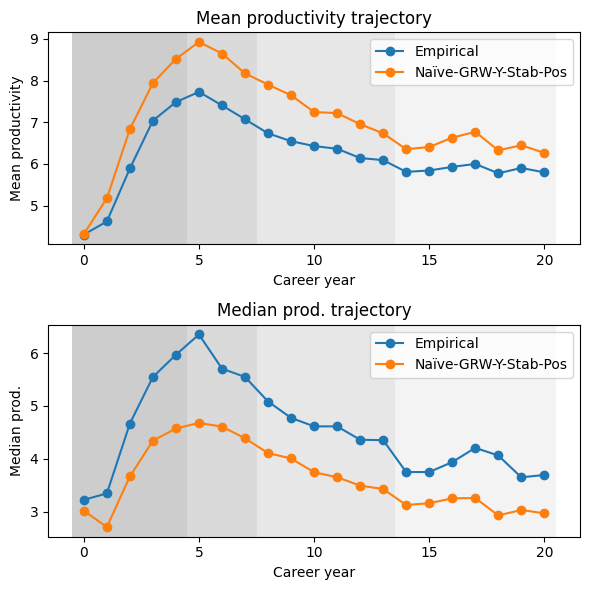

In [11]:
# Cell 8: canonical trajectory check

emp_mean = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].mean())

emp_median = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].median())

sim_mean = trajs_year_naive.mean(axis=1)
sim_median = np.median(trajs_year_naive, axis=1)

years = np.arange(Y + 1)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

axes[0].plot(emp_mean.index, emp_mean.values, marker="o", label="Empirical", zorder = 3)
axes[0].plot(years, sim_mean, marker="o", label=MODEL_NAME, zorder = 3)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean productivity")
axes[0].set_title("Mean productivity trajectory")
axes[0].legend()

axes[1].plot(emp_median.index, emp_median.values, marker="o", label="Empirical", zorder = 3)
axes[1].plot(years, sim_median, marker="o", label=MODEL_NAME, zorder = 3)
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Median prod.")
axes[1].set_title("Median prod. trajectory")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_prodSpaceMeanVsMedian.png", dpi=300, bbox_inches="tight")

plt.show()


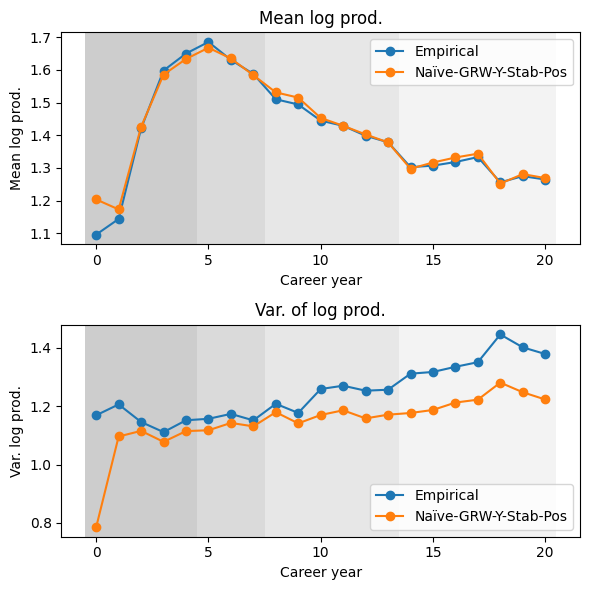

In [12]:
# Cell 9: yearwise log distribution diagnostics

years = np.arange(0, Y + 1)

emp_year_stats = []
for t in years:
    subset = working_df[working_df["CareerAge"] == t]
    q = subset["pubs_adj"].dropna()
    log_q = np.log(q + EPS)

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    emp_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod": log_q.mean(),
        "var_log_prod": log_q.var(ddof=0),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95)})

emp_year_stats = pd.DataFrame(emp_year_stats)

sim_year_stats = []
for t in years:
    q = pd.Series(trajs_year_naive[t])
    log_q = np.log(q + EPS)

    sim_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod": log_q.mean(),
        "var_log_prod": log_q.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95)})

sim_year_stats = pd.DataFrame(sim_year_stats)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)
axes[0].plot(emp_year_stats["year"], emp_year_stats["mean_log_prod"], marker="o", label="Empirical", zorder = 3)
axes[0].plot(sim_year_stats["year"], sim_year_stats["mean_log_prod"], marker="o", label=MODEL_NAME, zorder = 3)
axes[0].set_title("Mean log prod.")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean log prod.")
axes[0].legend()

axes[1].plot(emp_year_stats["year"], emp_year_stats["var_log_prod"], marker="o", label="Empirical", zorder = 3)
axes[1].plot(sim_year_stats["year"], sim_year_stats["var_log_prod"], marker="o", label=MODEL_NAME, zorder = 3)
axes[1].set_title("Var. of log prod.")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Var. log prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_logCompare.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
# Cell 10A: yearwise log-delta distrib dx func

def binned_mode(x, bins="auto"):
    x = pd.Series(x).dropna().to_numpy()

    if len(x) == 0:
        return np.nan

    if np.nanmin(x) == np.nanmax(x):
        return float(x[0])

    counts, edges = np.histogram(x, bins=bins)
    k = np.argmax(counts)

    return (edges[k] + edges[k + 1]) / 2


def make_log_delta_stats(df, year_col="CareerAge", delta_col="log_delta", Y=20):

    years = np.arange(0, Y)

    rows = []
    for t in years:
        subset = df[df[year_col] == t]
        dz = subset[delta_col].dropna()

        rows.append({
            "year": t,
            "n": len(dz),
            "mean_log_delta": dz.mean(),
            "median_log_delta": dz.median(),
            "mode_log_delta": binned_mode(dz),
            "var_log_delta": dz.var(ddof=0),
            "q25_log_delta": dz.quantile(0.25),
            "q50_log_delta": dz.quantile(0.50),
            "q75_log_delta": dz.quantile(0.75),
            "q90_log_delta": dz.quantile(0.90),
            "q95_log_delta": dz.quantile(0.95)})

    return pd.DataFrame(rows)

In [14]:
# Cell 10B: yearwise log delta stats get

emp_delta_stats = make_log_delta_stats(working_df_fit,year_col="CareerAge",delta_col="log_delta",Y=Y)

df_sim = trajectories_to_dataframe_naive(trajs)

sim_delta_stats = make_log_delta_stats(df_sim,year_col="CareerAge",delta_col="log_delta",Y=Y)

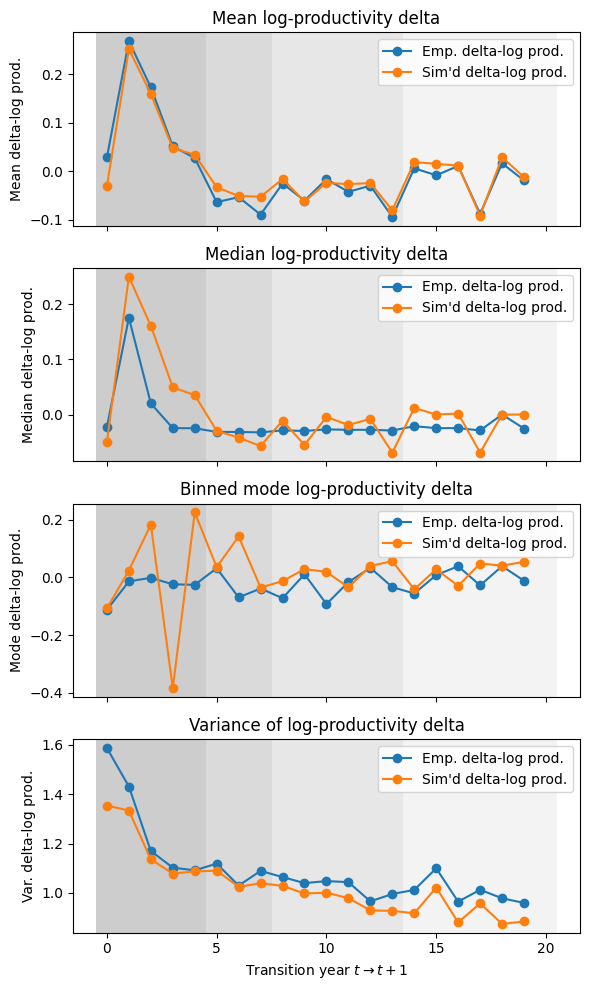

In [15]:
# Cell 11: plot yearwise log-delta moments

fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)


axes[0].plot(emp_delta_stats["year"],emp_delta_stats["mean_log_delta"],marker="o", label="Emp. delta-log prod.", zorder=3)
axes[0].plot(sim_delta_stats["year"],sim_delta_stats["mean_log_delta"],marker="o",label="Sim'd delta-log prod.", zorder=3)
axes[0].set_title("Mean log-productivity delta")
axes[0].set_ylabel("Mean delta-log prod.")
axes[0].legend()

axes[1].plot(emp_delta_stats["year"],emp_delta_stats["median_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[1].plot(sim_delta_stats["year"],sim_delta_stats["median_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[1].set_title("Median log-productivity delta")
axes[1].set_ylabel("Median delta-log prod.")
axes[1].legend()

axes[2].plot(emp_delta_stats["year"],emp_delta_stats["mode_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[2].plot(sim_delta_stats["year"],sim_delta_stats["mode_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[2].set_title("Binned mode log-productivity delta")
axes[2].set_ylabel("Mode delta-log prod.")
axes[2].legend()

axes[3].plot(emp_delta_stats["year"],emp_delta_stats["var_log_delta"],marker="o",label="Emp. delta-log prod.", zorder=3)
axes[3].plot(sim_delta_stats["year"],sim_delta_stats["var_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[3].set_title("Variance of log-productivity delta")
axes[3].set_xlabel("Transition year $t \\to t+1$")
axes[3].set_ylabel("Var. delta-log prod.")
axes[3].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_logDeltaMoments.png",dpi=300,bbox_inches="tight")
plt.show()

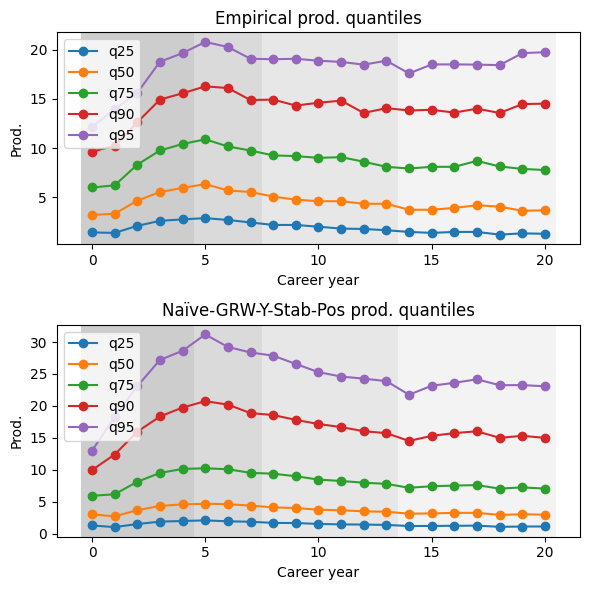

In [16]:
# Cell 12: yearwise productivity quantile diagnostics

qcols = ["q25_prod", "q50_prod", "q75_prod", "q90_prod", "q95_prod"]

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

for qcol in qcols:
    axes[0].plot(emp_year_stats["year"],emp_year_stats[qcol],marker="o",label=qcol.replace("_prod", ""), zorder = 3)

axes[0].set_title("Empirical prod. quantiles")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Prod.")
axes[0].legend()

for qcol in qcols:
    axes[1].plot(sim_year_stats["year"],sim_year_stats[qcol],marker="o",label=qcol.replace("_prod", ""), zorder = 3)

axes[1].set_title(f"{MODEL_NAME} prod. quantiles")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()

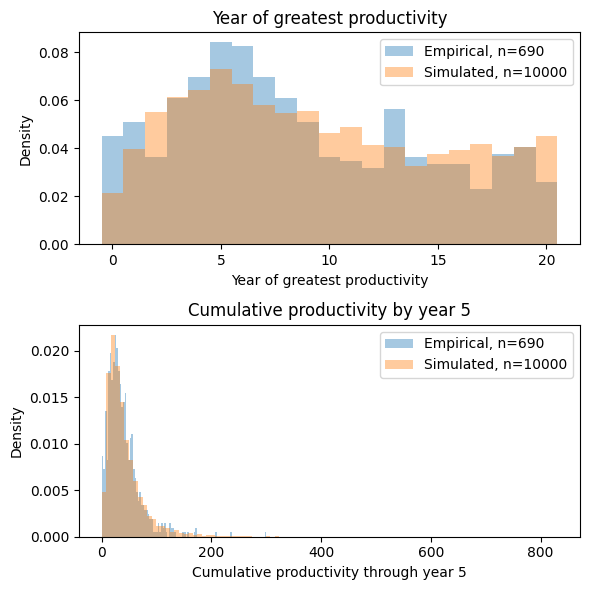

Full empirical trajectories: 690
Simulated trajectories: 10000
KS year of greatest productivity: KstestResult(statistic=np.float64(0.06552028985507247), pvalue=np.float64(0.007461130371690613), statistic_location=np.int64(8), statistic_sign=np.int8(1))
KS cumulative productivity by year 5: KstestResult(statistic=np.float64(0.04484927536231884), pvalue=np.float64(0.14431500405822079), statistic_location=np.float64(9.782551862831369), statistic_sign=np.int8(1))


In [17]:
# Cell 13: dx, norm'd

emp_panel = (working_df[working_df["CareerAge"].between(0, Y)].pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj"))

emp_panel_full = emp_panel.dropna()

emp_year_max = emp_panel_full.idxmax(axis=1)
emp_cum_y5 = emp_panel_full.loc[:, 0:5].sum(axis=1)

sim_year_max = np.argmax(trajs_year_naive, axis=0)
sim_cum_y5 = trajs_year_naive[0:6, :].sum(axis=0)

ks_year_max = stats.ks_2samp(emp_year_max, sim_year_max)
ks_cum_y5 = stats.ks_2samp(emp_cum_y5, sim_cum_y5)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

axes[0].hist(emp_year_max,bins=np.arange(-0.5, Y + 1.5, 1),alpha=0.4,density=True,label=f"Empirical, n={len(emp_year_max)}")

axes[0].hist(sim_year_max,bins=np.arange(-0.5, Y + 1.5, 1),alpha=0.4,density=True,label=f"Simulated, n={len(sim_year_max)}")

axes[0].set_xlabel("Year of greatest productivity")
axes[0].set_ylabel("Density")
axes[0].set_title("Year of greatest productivity")
axes[0].legend()

axes[1].hist(emp_cum_y5,bins=100,alpha=0.4,density=True,label=f"Empirical, n={len(emp_cum_y5)}")

axes[1].hist(sim_cum_y5,bins=100,alpha=0.4,density=True, label=f"Simulated, n={len(sim_cum_y5)}")

axes[1].set_xlabel("Cumulative productivity through year 5")
axes[1].set_ylabel("Density")
axes[1].set_title("Cumulative productivity by year 5")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / f'{MODEL_TAG}_compareDistribs')
plt.show()

print("Full empirical trajectories:", len(emp_panel_full))
print("Simulated trajectories:", trajs_year_naive.shape[1])
print("KS year of greatest productivity:", ks_year_max)
print("KS cumulative productivity by year 5:", ks_cum_y5)

In [18]:
# Cell 14: numerical summary

summary = {
    "empirical_mean_y0": emp_mean.loc[0],
    "empirical_mean_y5": emp_mean.loc[5],
    "empirical_mean_y10": emp_mean.loc[10],
    "empirical_mean_y20": emp_mean.loc[20],
    "simulated_mean_y0": sim_mean[0],
    "simulated_mean_y5": sim_mean[5],
    "simulated_mean_y10": sim_mean[10],
    "simulated_mean_y20": sim_mean[20],
    "empirical_median_y0": emp_median.loc[0],
    "empirical_median_y5": emp_median.loc[5],
    "empirical_median_y10": emp_median.loc[10],
    "empirical_median_y20": emp_median.loc[20],
    "simulated_median_y0": sim_median[0],
    "simulated_median_y5": sim_median[5],
    "simulated_median_y10": sim_median[10],
    "simulated_median_y20": sim_median[20],
    "simulated_y20_q95": np.quantile(trajs_year_naive[20], 0.95),
    "simulated_y20_q99": np.quantile(trajs_year_naive[20], 0.99),
    "simulated_y20_max": np.max(trajs_year_naive[20]),
    "ks_year_max_stat": ks_year_max.statistic,
    "ks_year_max_p": ks_year_max.pvalue,
    "ks_cum_y5_stat": ks_cum_y5.statistic,
    "ks_cum_y5_p": ks_cum_y5.pvalue,
}

summary_df = pd.DataFrame([summary])

print("Yearwise log-prod params")
display(year_logprod_params)

print("Yearwise naive log-delta params")
display(year_delta_params)

print("Summary")
display(summary_df)

Yearwise log-prod params


,year,n,mean_log_productivity,var_log_productivity,sd_log_productivity
0,0,2069,1.096164,1.169240,1.081314
1,1,2149,1.143948,1.206474,1.098396
2,2,2208,1.420733,1.146156,1.070587
3,3,2252,1.597963,1.111421,1.054239
4,4,2283,1.649832,1.152084,1.073352
5,5,2277,1.685266,1.157075,1.075674
6,6,2214,1.630428,1.173957,1.083493
7,7,2156,1.587435,1.151704,1.073175
8,8,2074,1.510005,1.208534,1.099334
9,9,1992,1.494018,1.177235,1.085005


Yearwise naive log-delta params


,year,n,intercept_log_delta,beta_log_prod,sigma_log_delta,mean_log_delta,sample_sd_log_delta
0,0,2067,0.742623,-0.650781,1.044612,0.028980,1.259683
1,1,2143,0.966299,-0.609270,0.991072,0.268758,1.196293
2,2,2202,0.912463,-0.519398,0.927570,0.173335,1.081619
3,3,2247,0.808968,-0.473417,0.923766,0.051549,1.050041
4,4,2259,0.808450,-0.471010,0.914065,0.027380,1.044818
5,5,2200,0.739552,-0.474055,0.924041,-0.063831,1.057698
6,6,2142,0.679839,-0.446699,0.890070,-0.053350,1.014904
7,7,2059,0.626020,-0.447022,0.923991,-0.089495,1.043648
8,8,1985,0.662685,-0.452871,0.900615,-0.025281,1.031750
9,9,1895,0.553715,-0.407888,0.915138,-0.060497,1.019692


Summary


,empirical_mean_y0,empirical_mean_y5,empirical_mean_y10,empirical_mean_y20,simulated_mean_y0,simulated_mean_y5,simulated_mean_y10,simulated_mean_y20,empirical_median_y0,empirical_median_y5,...,simulated_median_y5,simulated_median_y10,simulated_median_y20,simulated_y20_q95,simulated_y20_q99,simulated_y20_max,ks_year_max_stat,ks_year_max_p,ks_cum_y5_stat,ks_cum_y5_p
0,4.304679,7.729319,6.428626,5.797863,4.318665,8.926961,7.24481,6.264975,3.225469,6.352937,...,4.679094,3.746527,2.969145,23.06866,48.978718,200.613548,0.06552,0.007461,0.044849,0.144315


In [19]:
# Cell 15: save outputs

year_logprod_params.to_csv(RESULTS / f"{MODEL_TAG}_stageLogProdParams.csv", index=False)
year_delta_params.to_csv(RESULTS / f"{MODEL_TAG}_stageLogParams.csv", index=False)
global_delta_params.to_csv(RESULTS / f"{MODEL_TAG}_globalParams.csv", index=False)
emp_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_empYearStats.csv", index=False)
sim_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_simYearStats.csv", index=False)
summary_df.to_csv(RESULTS / f"{MODEL_TAG}_Summary.csv", index=False)
emp_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_empLogDeltaStats.csv",index=False)
sim_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_simLogDeltaStats.csv",index=False)

with open(RESULTS / f"{MODEL_TAG}_report.txt", "w") as f:
    f.write("Naïve-GRW-Y report\n")
    f.write("\n\n")

    f.write("Model\n")
    f.write("\n")
    f.write("z_{t+1} = z_t + error_t\n")
    f.write("where z_t = log(pubs_adj_t + EPS).\n")
    f.write("error_t ~ Normal(mean_log_delta_t, sigma_log_delta_t^2).\n\n")

    f.write(f"EPS = {EPS}\n")
    f.write(f"N = {N}\n")
    f.write(f"Y = {Y}\n\n")

    f.write("Yearwise log-productivity parameters\n")
    f.write("\n")
    f.write(year_logprod_params.to_string(index=False))

    f.write("\n\nYearwise naive log-delta parameters\n")
    f.write("\n")
    f.write(year_delta_params.to_string(index=False))

    f.write("\n\nGlobal naive log-delta parameters\n")
    f.write("\n")
    f.write(global_delta_params.to_string(index=False))

    f.write("\n\nsummary\n")
    f.write("-------\n")
    f.write(summary_df.to_string(index=False))


In [20]:
OUT = PROJ_ROOT / "data" / 'trajectory_correlation_data'

TRJ = trajs     

TRJ = np.asarray(TRJ)
if TRJ.shape[0] != 21 and TRJ.shape[1] == 21:
    TRJ = TRJ.T

assert TRJ.shape[0] == 21, f"expected 21 years, got {TRJ.shape}"

save_path = OUT / f"{MODEL_TAG}_trajs.npy"
np.save(save_path, TRJ)


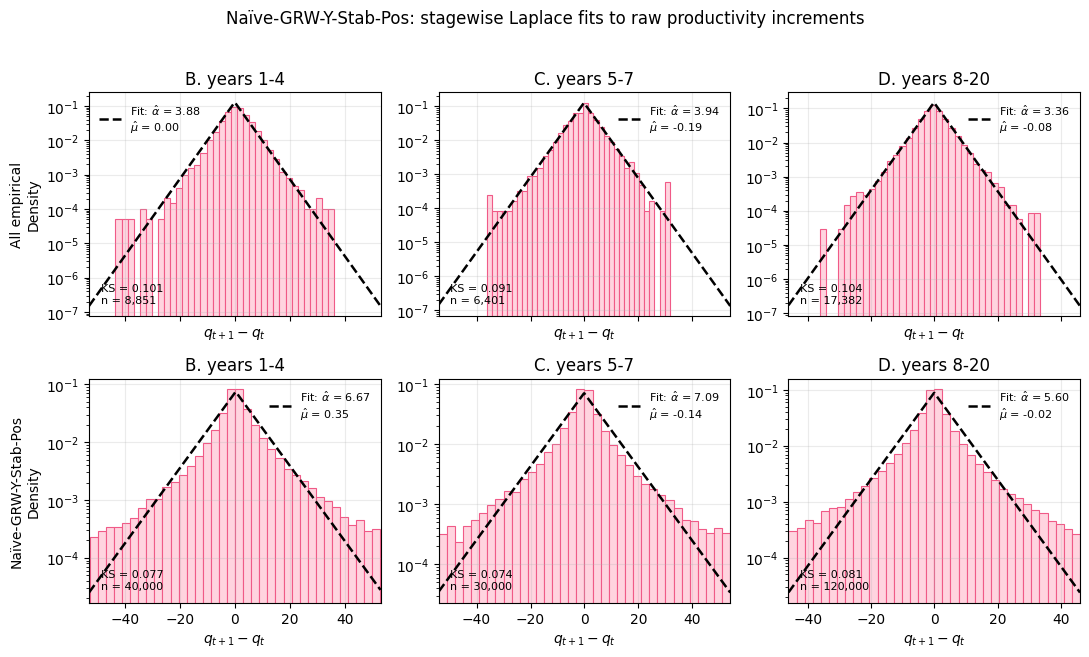

,model,source,stage,n,mu_hat,alpha_hat,ks_stat,mean,sd,q01,q50,q99
0,All empirical,empirical,B. years 1-4,8851,0.000000,3.879470,0.101040,0.756686,5.414004,-13.371327,0.000000,15.428888
1,All empirical,empirical,C. years 5-7,6401,-0.190708,3.937165,0.090950,-0.429310,5.622345,-15.275857,-0.190708,15.502144
2,All empirical,empirical,D. years 8-20,17382,-0.079308,3.363053,0.104041,-0.220967,4.886889,-13.966737,-0.079308,13.732907
3,Naïve-GRW-Y-Stab-Pos,simulated,B. years 1-4,40000,0.349166,6.670623,0.077034,0.937813,14.118927,-34.079661,0.349166,41.717272
4,Naïve-GRW-Y-Stab-Pos,simulated,C. years 5-7,30000,-0.137560,7.089375,0.073745,-0.341035,14.217544,-42.437081,-0.137560,41.525339
5,Naïve-GRW-Y-Stab-Pos,simulated,D. years 8-20,120000,-0.016838,5.597051,0.081226,-0.136573,12.013673,-35.258742,-0.016838,34.257742


In [21]:
# cell 17: laplace

stage_years = {
    "B. years 1-4": np.arange(1, 5),
    "C. years 5-7": np.arange(5, 8),
    "D. years 8-20": np.arange(8, Y)}

def laplace_fit(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    mu = np.median(x)
    alpha = np.mean(np.abs(x - mu))
    ks = stats.kstest(x, "laplace", args=(mu, alpha)).statistic
    return mu, alpha, ks, len(x)

def laplace_pdf(x, mu, alpha):
    return (1 / (2 * alpha)) * np.exp(-np.abs(x - mu) / alpha)

def sim_stage_dx(trj, yrs):
    dx = trj[1:, :] - trj[:-1, :]
    return dx[yrs, :].ravel()

def emp_stage_dx(working_df, yrs):
    emp_dx = working_df.sort_values(["dblp_id", "CareerAge"]).copy()
    emp_dx["pubs_adj_next"] = emp_dx.groupby("dblp_id")["pubs_adj"].shift(-1)
    emp_dx["CareerAge_next"] = emp_dx.groupby("dblp_id")["CareerAge"].shift(-1)
    emp_dx["raw_delta"] = emp_dx["pubs_adj_next"] - emp_dx["pubs_adj"]

    keep = emp_dx["CareerAge_next"].eq(emp_dx["CareerAge"] + 1)
    keep &= emp_dx["CareerAge"].isin(yrs)

    return emp_dx.loc[keep, "raw_delta"].dropna().to_numpy()

plot_sources = [(MODEL_NAME, "simulated", TRJ)]

plot_sources = [("All empirical", "empirical", None)] + plot_sources

laplace_rows = []

xlims = {}
for stage, yrs in stage_years.items():
    pooled = []
    pooled.append(emp_stage_dx(working_df, yrs))

    pooled.append(sim_stage_dx(TRJ, yrs))

    pooled = np.concatenate([x for x in pooled if len(x) > 0])
    lo, hi = np.quantile(pooled, [0.005, 0.995])
    lim = max(abs(lo), abs(hi), 1)
    xlims[stage] = (-lim, lim)

fig, axes = plt.subplots(len(plot_sources), 3, figsize=(11, 3.2 * len(plot_sources)), sharex="col", sharey=False)

if len(plot_sources) == 1:
    axes = np.array([axes])

for r, (source_name, source_type, trj) in enumerate(plot_sources):
    for c, (stage, yrs) in enumerate(stage_years.items()):
        ax = axes[r, c]

        if source_type == "empirical":
            x = emp_stage_dx(working_df, yrs)
        else:
            x = sim_stage_dx(trj, yrs)

        mu, alpha, ks, n = laplace_fit(x)
        lo, hi = xlims[stage]
        x_plot = x[(x >= lo) & (x <= hi)]

        ax.hist(x_plot,bins=36,density=True,color="#ffd4df",edgecolor="#f05a87",linewidth=0.8)

        xx = np.linspace(lo, hi, 600)
        ax.plot(xx,laplace_pdf(xx, mu, alpha),linestyle="--",color="black",linewidth=1.8,label=rf"Fit: $\hat\alpha$ = {alpha:.2f}" + "\n" + rf"$\hat\mu$ = {mu:.2f}")

        ax.set_yscale("log")
        ax.set_xlim(lo, hi)
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
        ax.set_title(stage)
        ax.set_xlabel(r"$q_{t+1} - q_t$")

        if c == 0:
            ax.set_ylabel(f"{source_name}\nDensity")

        ax.text(0.04,0.06,f"KS = {ks:.3f}\nn = {n:,}",transform=ax.transAxes,fontsize=8)

        laplace_rows.append({
            "model": source_name,
            "source": source_type,
            "stage": stage,
            "n": n,
            "mu_hat": mu,
            "alpha_hat": alpha,
            "ks_stat": ks,
            "mean": np.mean(x),
            "sd": np.std(x, ddof=0),
            "q01": np.quantile(x, 0.01),
            "q50": np.quantile(x, 0.50),
            "q99": np.quantile(x, 0.99)})

fig.suptitle(f"{MODEL_NAME}: stagewise Laplace fits to raw productivity increments", y=1.02)
fig.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_stageRawIncrementLaplace.png", dpi=300, bbox_inches="tight")
plt.show()

laplace_stage_summary = pd.DataFrame(laplace_rows)
laplace_stage_summary.to_csv(RESULTS / f"{MODEL_TAG}_stageRawIncrementLaplace.csv", index=False)
laplace_stage_summary

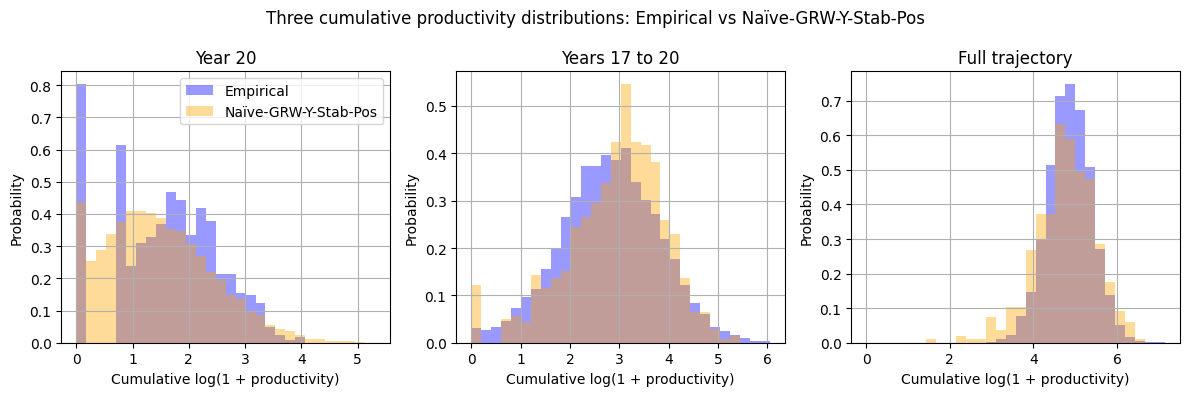

In [22]:
lastyear_sim = trajs[20]
lastyear_emp = emp_panel_full[20]
hist_bins_lastyear = np.histogram_bin_edges((np.log1p(np.concat([[0],lastyear_sim, lastyear_emp]))),bins=30)

lastfour_sim = trajs[-4:,:].sum(axis = 0)
lastfour_emp = emp_panel_full.iloc[:, -4:].sum(axis=1).to_numpy()
hist_bins_lastfour = np.histogram_bin_edges((np.log1p(np.concat([[0],lastfour_sim, lastfour_emp]))),bins=30)

cumsim = trajs.sum(axis = 0)
cumemp = emp_panel_full.sum(axis=1).to_numpy()
hist_bins_cum = np.histogram_bin_edges((np.log1p(np.concat([[0],cumsim, cumemp]))),bins=30)


fig, ax = plt.subplots(1,3, figsize = (12,4))

ax[0].hist(np.log1p(lastyear_emp), bins = hist_bins_lastyear, alpha = 0.4, color = 'blue', label = 'Empirical', density = True)
ax[0].hist(np.log1p(lastyear_sim),bins=hist_bins_lastyear, alpha = 0.4, color = 'orange', label= f'{MODEL_NAME}', density=True)
ax[0].set_xlabel('Cumulative log(1 + productivity)')
ax[0].set_ylabel('Probability')
ax[0].set_title('Year 20')
ax[0].legend()
ax[0].grid(True)

ax[1].hist(np.log1p(lastfour_sim), bins = hist_bins_lastfour, alpha = 0.4, color = 'blue', label= f'{MODEL_NAME}', density = True)
ax[1].hist(np.log1p(lastfour_emp),bins=hist_bins_lastfour, alpha = 0.4, color = 'orange', label= 'Empirical', density=True)
ax[1].set_xlabel('Cumulative log(1 + productivity)')
ax[1].set_ylabel('Probability')
ax[1].set_title('Years 17 to 20')
ax[1].grid(True)

ax[2].hist(np.log1p(cumsim), bins = hist_bins_cum, alpha = 0.4, color = 'blue', label = f'{MODEL_NAME}', density = True)
ax[2].hist(np.log1p(cumemp), bins=hist_bins_cum, alpha = 0.4, color = 'orange', label='Empirical', density=True)
ax[2].set_xlabel('Cumulative log(1 + productivity)')
ax[2].set_ylabel('Probability')
ax[2].set_title('Full trajectory')
ax[2].grid(True)

plt.suptitle(f'Three cumulative productivity distributions: Empirical vs {MODEL_NAME}')
plt.tight_layout()
plt.show()

fig.savefig(FIGURES / f"{MODEL_TAG}_threecumdists.png",dpi=300, bbox_inches="tight")

In [23]:
# shape_sim, loc_sim, scale_sim = stats.lognorm.fit(np.asarray(cumsim + 0.49), floc=0)
# shape_emp, loc_emp, scale_emp = stats.lognorm.fit(np.asarray(cumemp + 0.49), floc = 0)
# ks_sim = stats.kstest(np.asarray(cumsim) + 0.49, stats.lognorm.cdf, args=(shape_sim, loc_sim, scale_sim))
# ks_emp = stats.kstest(np.asarray(cumemp) + 0.49, stats.lognorm.cdf, args=(shape_emp, loc_emp, scale_emp))

# # ks_sim_text = f"KS = {ks_sim.statistic:.4f}\np = {ks_sim.pvalue:.4g}"
# # ks_emp_text = f"KS = {ks_emp.statistic:.4f}\np = {ks_emp.pvalue:.4g}"

# ks_sim_text = f"KS D = {ks_sim.statistic:.4f}\np = {ks_sim.pvalue:.3g}\nn = {len(cumsim):,}"
# ks_emp_text = f"KS D = {ks_emp.statistic:.4f}\np = {ks_emp.pvalue:.3g}\nn = {len(cumemp):,}"

# fig, ax = plt.subplots(1,2, figsize=(10, 5))

# stats.probplot(np.asarray(cumsim + 0.49),dist=stats.lognorm,sparams=(shape_sim, loc_sim, scale_sim),plot=ax[0])
# stats.probplot(np.asarray(cumemp + 0.49),dist=stats.lognorm,sparams=(shape_emp, loc_emp, scale_emp),plot=ax[1])

# ax[0].set_title(f"{MODEL_NAME}")
# ax[0].set_xlabel("Theoretical lognormal quantiles")
# ax[0].set_ylabel("Observed data quantiles")
# ax[0].grid(True)
# ax[0].text(0.05, 0.95,ks_sim_text,transform=ax[0].transAxes,va="top",ha="left",fontsize=10,bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))


# ax[1].set_title('Empirical')
# ax[1].set_xlabel("Theoretical lognormal quantiles")
# ax[1].set_ylabel("Observed data quantiles")
# ax[1].grid(True)
# ax[1].text(0.05, 0.95,ks_emp_text,transform=ax[1].transAxes,va="top",ha="left",fontsize=10,bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))


# plt.suptitle(f'QQ Plots for {MODEL_NAME} and Empirical Data Against Lognormal')
# plt.tight_layout()

# fig.savefig(FIGURES / f"{MODEL_TAG}_qqlognorm_full.png",dpi=300, bbox_inches="tight")

# plt.show()


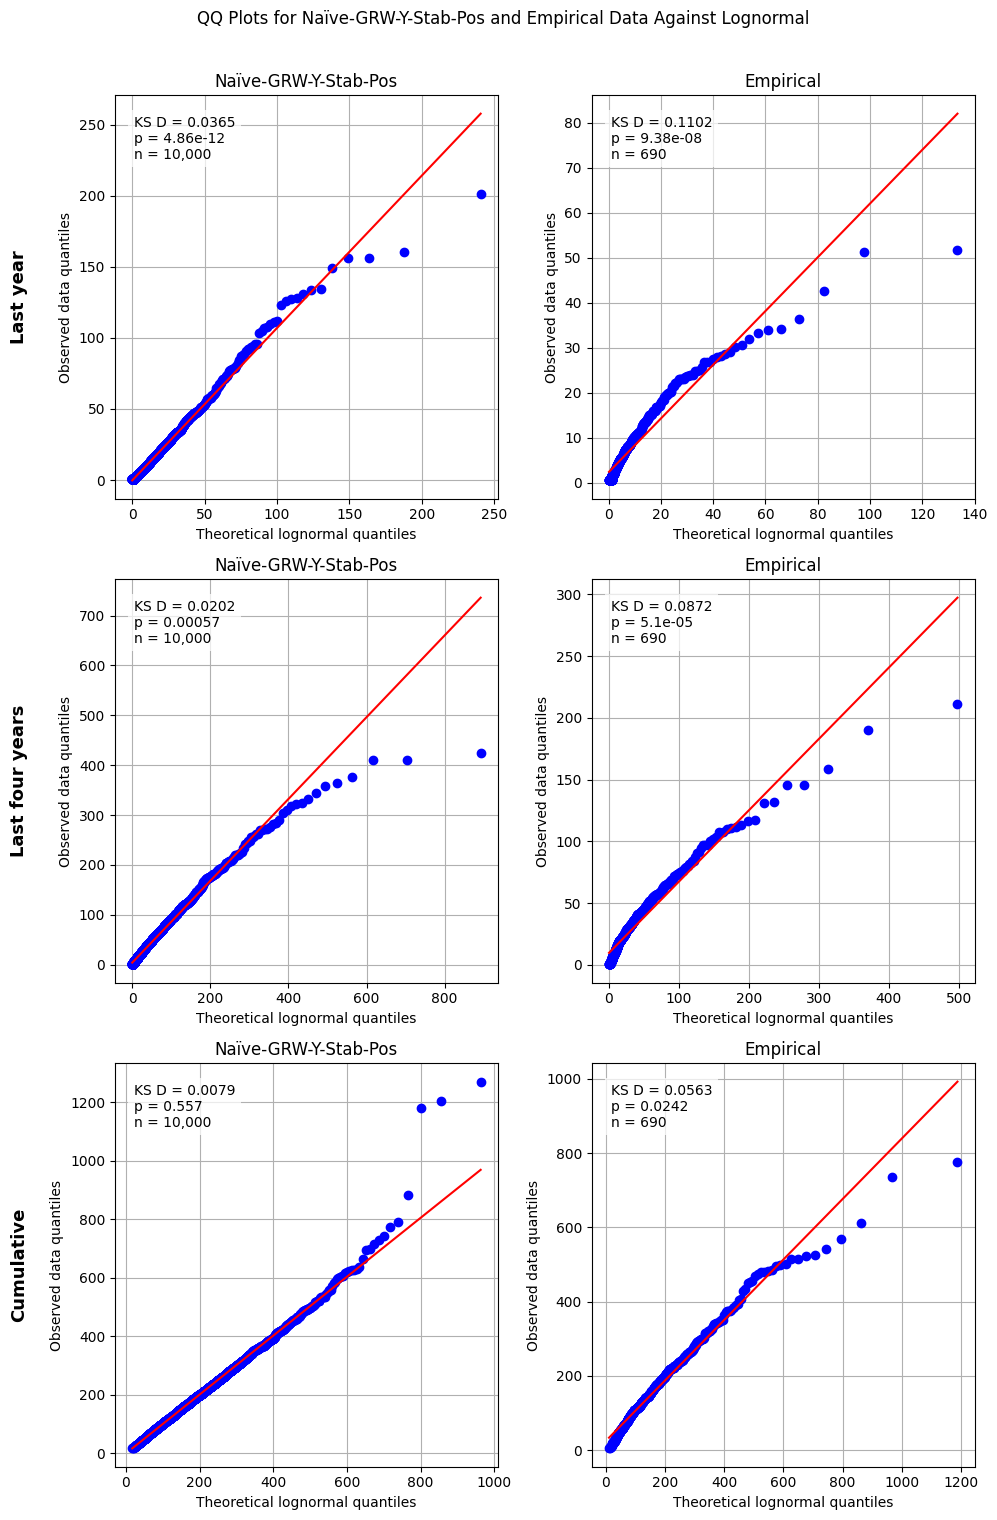

In [24]:

shape_sim_lastyear, loc_sim_lastyear, scale_sim_lastyear = stats.lognorm.fit(np.asarray(lastyear_sim + 0.49), floc=0)
shape_emp_lastyear, loc_emp_lastyear, scale_emp_lastyear = stats.lognorm.fit(np.asarray(lastyear_emp + 0.49), floc = 0)
ks_sim_lastyear = stats.kstest(np.asarray(lastyear_sim) + 0.49, stats.lognorm.cdf, args=(shape_sim_lastyear, loc_sim_lastyear, scale_sim_lastyear))
ks_emp_lastyear = stats.kstest(np.asarray(lastyear_emp) + 0.49, stats.lognorm.cdf, args=(shape_emp_lastyear, loc_emp_lastyear, scale_emp_lastyear))
ks_sim_text_lastyear = f"KS D = {ks_sim_lastyear.statistic:.4f}\np = {ks_sim_lastyear.pvalue:.3g}\nn = {len(lastyear_sim):,}"
ks_emp_text_lastyear = f"KS D = {ks_emp_lastyear.statistic:.4f}\np = {ks_emp_lastyear.pvalue:.3g}\nn = {len(lastyear_emp):,}"



#####


shape_sim_lastfour, loc_sim_lastfour, scale_sim_lastfour = stats.lognorm.fit(np.asarray(lastfour_sim + 0.49), floc=0)
shape_emp_lastfour, loc_emp_lastfour, scale_emp_lastfour = stats.lognorm.fit(np.asarray(lastfour_emp + 0.49), floc = 0)
ks_sim_lastfour = stats.kstest(np.asarray(lastfour_sim) + 0.49, stats.lognorm.cdf, args=(shape_sim_lastfour, loc_sim_lastfour, scale_sim_lastfour))
ks_emp_lastfour = stats.kstest(np.asarray(lastfour_emp) + 0.49, stats.lognorm.cdf, args=(shape_emp_lastfour, loc_emp_lastfour, scale_emp_lastfour))
ks_sim_text_lastfour = f"KS D = {ks_sim_lastfour.statistic:.4f}\np = {ks_sim_lastfour.pvalue:.3g}\nn = {len(lastfour_sim):,}"
ks_emp_text_lastfour = f"KS D = {ks_emp_lastfour.statistic:.4f}\np = {ks_emp_lastfour.pvalue:.3g}\nn = {len(lastfour_emp):,}"


#####


shape_sim_cum, loc_sim_cum, scale_sim_cum = stats.lognorm.fit(np.asarray(cumsim + 0.49), floc=0)
shape_emp_cum, loc_emp_cum, scale_emp_cum = stats.lognorm.fit(np.asarray(cumemp + 0.49), floc = 0)
ks_sim_cum = stats.kstest(np.asarray(cumsim) + 0.49, stats.lognorm.cdf, args=(shape_sim_cum, loc_sim_cum, scale_sim_cum))
ks_emp_cum = stats.kstest(np.asarray(cumemp) + 0.49, stats.lognorm.cdf, args=(shape_emp_cum, loc_emp_cum, scale_emp_cum))
ks_sim_text_cum = f"KS D = {ks_sim_cum.statistic:.4f}\np = {ks_sim_cum.pvalue:.3g}\nn = {len(cumsim):,}"
ks_emp_text_cum = f"KS D = {ks_emp_cum.statistic:.4f}\np = {ks_emp_cum.pvalue:.3g}\nn = {len(cumemp):,}"


#####


EPS = 0.49

fig, ax = plt.subplots(3,2, figsize=(10, 15))

qq_rows = [
    ("Last year", lastyear_sim, lastyear_emp,
     (shape_sim_lastyear, loc_sim_lastyear, scale_sim_lastyear),
     (shape_emp_lastyear, loc_emp_lastyear, scale_emp_lastyear),
     ks_sim_text_lastyear, ks_emp_text_lastyear),

    ("Last four years", lastfour_sim, lastfour_emp,
     (shape_sim_lastfour, loc_sim_lastfour, scale_sim_lastfour),
     (shape_emp_lastfour, loc_emp_lastfour, scale_emp_lastfour),
     ks_sim_text_lastfour, ks_emp_text_lastfour),

    ("Cumulative", cumsim, cumemp,
     (shape_sim_cum, loc_sim_cum, scale_sim_cum),
     (shape_emp_cum, loc_emp_cum, scale_emp_cum),
     ks_sim_text_cum, ks_emp_text_cum),
]

for r, (row_title, sim, emp, sim_params, emp_params, sim_text, emp_text) in enumerate(qq_rows):

    stats.probplot(np.asarray(sim, dtype=float) + EPS, dist=stats.lognorm, sparams=sim_params, plot=ax[r,0])
    stats.probplot(np.asarray(emp, dtype=float) + EPS, dist=stats.lognorm, sparams=emp_params, plot=ax[r,1])

    ax[r,0].set_title(f"{MODEL_NAME}")
    ax[r,1].set_title("Empirical")

    for c, ks_text in enumerate([sim_text, emp_text]):
        ax[r,c].set_xlabel("Theoretical lognormal quantiles")
        ax[r,c].set_ylabel("Observed data quantiles")
        ax[r,c].grid(True)
        ax[r,c].text(0.05, 0.95, ks_text, transform=ax[r,c].transAxes,
                     va="top", ha="left", fontsize=10,
                     bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

    ax[r,0].annotate(row_title, xy=(-0.25, 0.5), xycoords="axes fraction",
                     rotation=90, va="center", ha="center",
                     fontsize=13, fontweight="bold")

plt.suptitle(f"QQ Plots for {MODEL_NAME} and Empirical Data Against Lognormal", y=1.01)
plt.tight_layout()

fig.savefig(FIGURES / f"{MODEL_TAG}_qqlognorm_full.png", dpi=300, bbox_inches="tight")
plt.show()

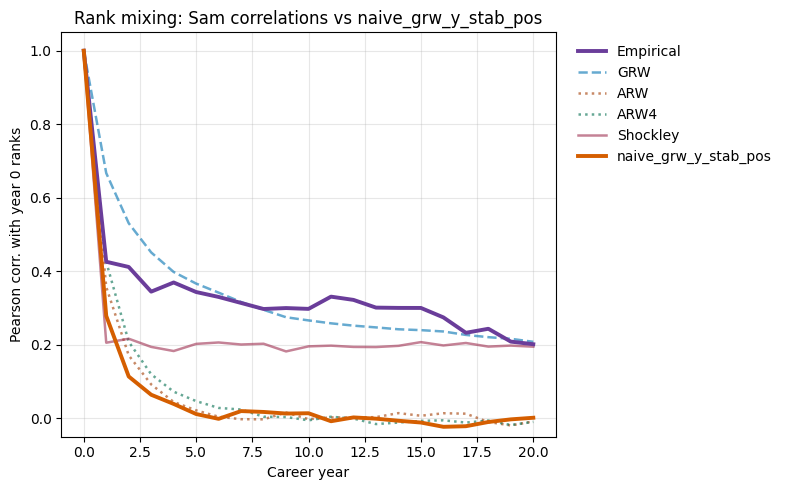

In [25]:
OUT = PROJ_ROOT / "data" / "trajectory_correlation_data"

sams_corr = pd.read_csv(OUT / "sams_correlations.csv")

TRJ = np.asarray(trajs)
rank_0 = pd.Series(TRJ[0]).rank(method="average").to_numpy()

corr_traj = []
for t in range(Y + 1):
    rank_t = pd.Series(TRJ[t]).rank(method="average").to_numpy()
    corr_traj.append(np.corrcoef(rank_0, rank_t)[0, 1])

corr_traj = pd.DataFrame({
    "CareerAge": np.arange(Y + 1),
    MODEL_TAG: corr_traj,})

palette = ["#0072B2", "#A23B00", "#006D4E", "#6A3D9A", "#9E2F50", "#D55E00"]

sams_corr.insert(0, "CareerAge", np.arange(len(sams_corr)))

corr_compare = sams_corr.merge(corr_traj, on="CareerAge", how="left")
corr_compare.to_csv(OUT / f"{MODEL_TAG}_corrCompare.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(corr_compare["CareerAge"], corr_compare["CS_empirical"], color=palette[3], linewidth=2.8, label="Empirical", zorder=6)
ax.plot(corr_compare["CareerAge"], corr_compare["GRW"], color=palette[0], linestyle="dashed", linewidth=1.8, alpha=0.6, label="GRW")
ax.plot(corr_compare["CareerAge"], corr_compare["ARW"], color=palette[1], linestyle="dotted", linewidth=1.8, alpha=0.6, label="ARW")
ax.plot(corr_compare["CareerAge"], corr_compare["ARW4"], color=palette[2], linestyle="dotted", linewidth=1.8, alpha=0.6, label="ARW4")
ax.plot(corr_compare["CareerAge"], corr_compare["Shockley"], color=palette[4], linewidth=1.8, alpha=0.6, label="Shockley")

ax.plot(corr_compare["CareerAge"], corr_compare[MODEL_TAG], color=palette[5], linewidth=2.8, label=MODEL_TAG, zorder=7)

ax.set_title(f"Rank mixing: Sam correlations vs {MODEL_TAG}")
ax.set_xlabel("Career year")
ax.set_ylabel("Pearson corr. with year 0 ranks")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(OUT / f"{MODEL_TAG}_corrCompare.png", dpi=300, bbox_inches="tight")
plt.show()


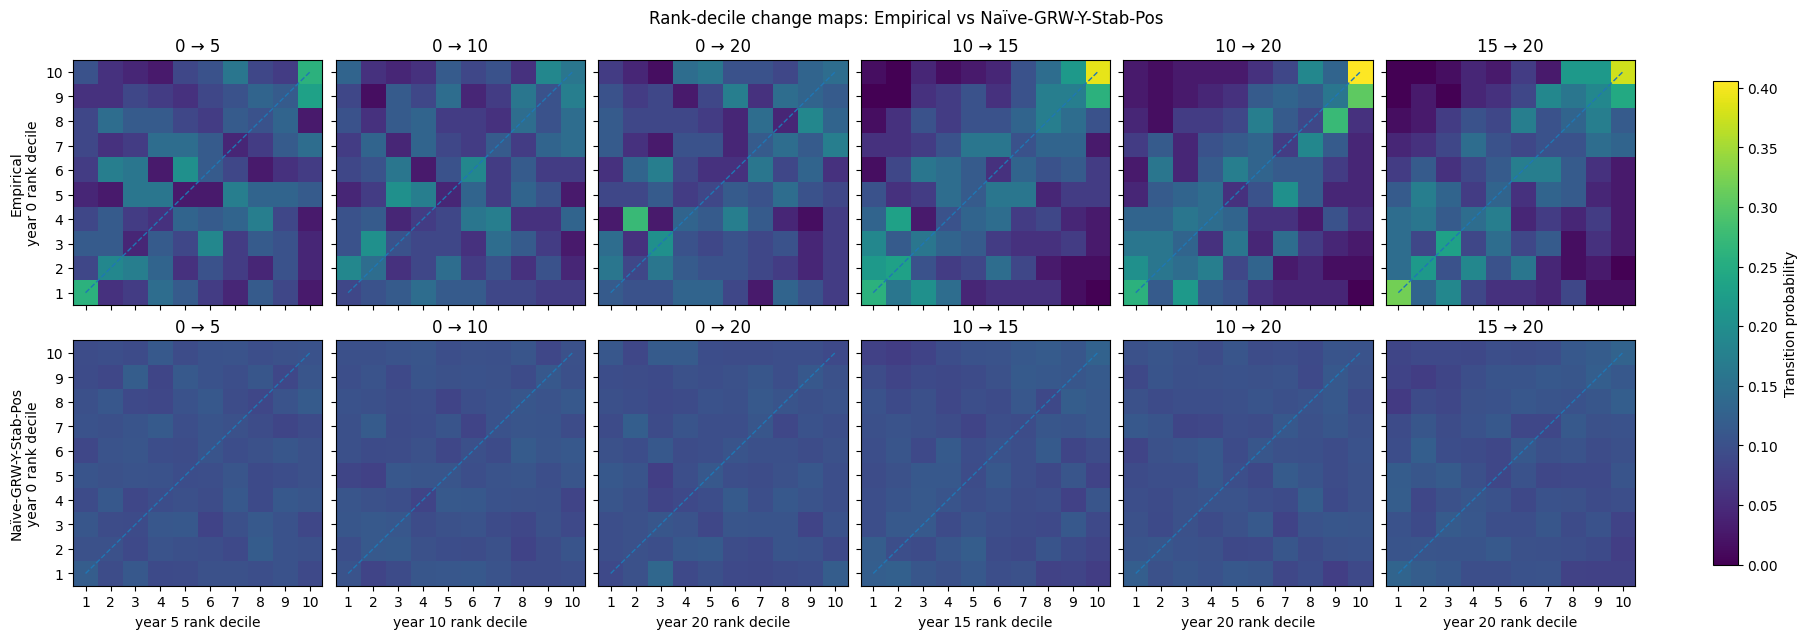

In [26]:
rank_pairs = [(0, 5), (0, 10), (0, 20), (10, 15), (10, 20), (15, 20)]

def orient_trj(A):
    A = np.asarray(A)
    if A.shape[0] == Y + 1:
        return A.T
    if A.shape[1] == Y + 1:
        return A
    raise ValueError(f"bad traj shape {A.shape}")

def rank_deciles(mat, year, n_deciles=10, seed=63):
    x = np.asarray(mat[:, year])
    rng = np.random.default_rng(seed + year)
    tmp = pd.DataFrame({"x": x,"tie": rng.random(len(x)),"idx": np.arange(len(x))})
    tmp = tmp.sort_values(["x", "tie"])
    tmp["decile"] = np.ceil(np.arange(1, len(tmp) + 1) / len(tmp) * n_deciles).astype(int)
    tmp["decile"] = tmp["decile"].clip(1, n_deciles)
    return tmp.sort_values("idx")["decile"].to_numpy()

def decile_change_probs(mat, start, end, n_deciles=10):
    start_decile = rank_deciles(mat, start, n_deciles=n_deciles)
    end_decile = rank_deciles(mat, end, n_deciles=n_deciles)

    counts = pd.crosstab(
        start_decile,
        end_decile,
        rownames=[f"year {start} decile"],
        colnames=[f"year {end} decile"],
        dropna=False)

    counts = counts.reindex(
        index=np.arange(1, n_deciles + 1),
        columns=np.arange(1, n_deciles + 1),
        fill_value=0)

    return counts.div(counts.sum(axis=1), axis=0)

emp_panel_rank = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .pivot_table(index="dblp_id",columns="CareerAge",values="pubs_adj")
    .reindex(columns=np.arange(Y + 1))
    .dropna())

emp_rank_mat = emp_panel_rank.to_numpy()
sim_rank_mat = orient_trj(trajs)

rank_maps = {}
for start, end in rank_pairs:
    rank_maps[("Empirical", start, end)] = decile_change_probs(emp_rank_mat, start, end)
    rank_maps[(MODEL_NAME, start, end)] = decile_change_probs(sim_rank_mat, start, end)

vmax = max(x.to_numpy().max() for x in rank_maps.values())

fig, axes = plt.subplots(2, len(rank_pairs), figsize=(18, 6), sharex=True, sharey=True, constrained_layout=True)

for c, (start, end) in enumerate(rank_pairs):
    for r, label in enumerate(["Empirical", MODEL_NAME]):
        ax = axes[r, c]
        probs = rank_maps[(label, start, end)]

        im = ax.imshow(probs,origin="lower",aspect="auto",vmin=0,vmax=vmax,interpolation="nearest")

        ax.plot(np.arange(10),np.arange(10),linestyle="--",linewidth=1)
        ax.set_title(f"{start} → {end}")

        ax.set_xticks(np.arange(10))
        ax.set_xticklabels(np.arange(1, 11))
        ax.set_yticks(np.arange(10))
        ax.set_yticklabels(np.arange(1, 11))

        if r == 1:
            ax.set_xlabel(f"year {end} rank decile")
        if c == 0:
            ax.set_ylabel(f"{label}\nyear {start} rank decile")

cbar = fig.colorbar(im, ax=axes, shrink=0.92)
cbar.set_label("Transition probability")

fig.suptitle(f"Rank-decile change maps: Empirical vs {MODEL_NAME}", y=1.04)

plt.savefig(FIGURES / f"{MODEL_TAG}_rankDecileChangeMaps.png", dpi=300, bbox_inches="tight")
plt.show()

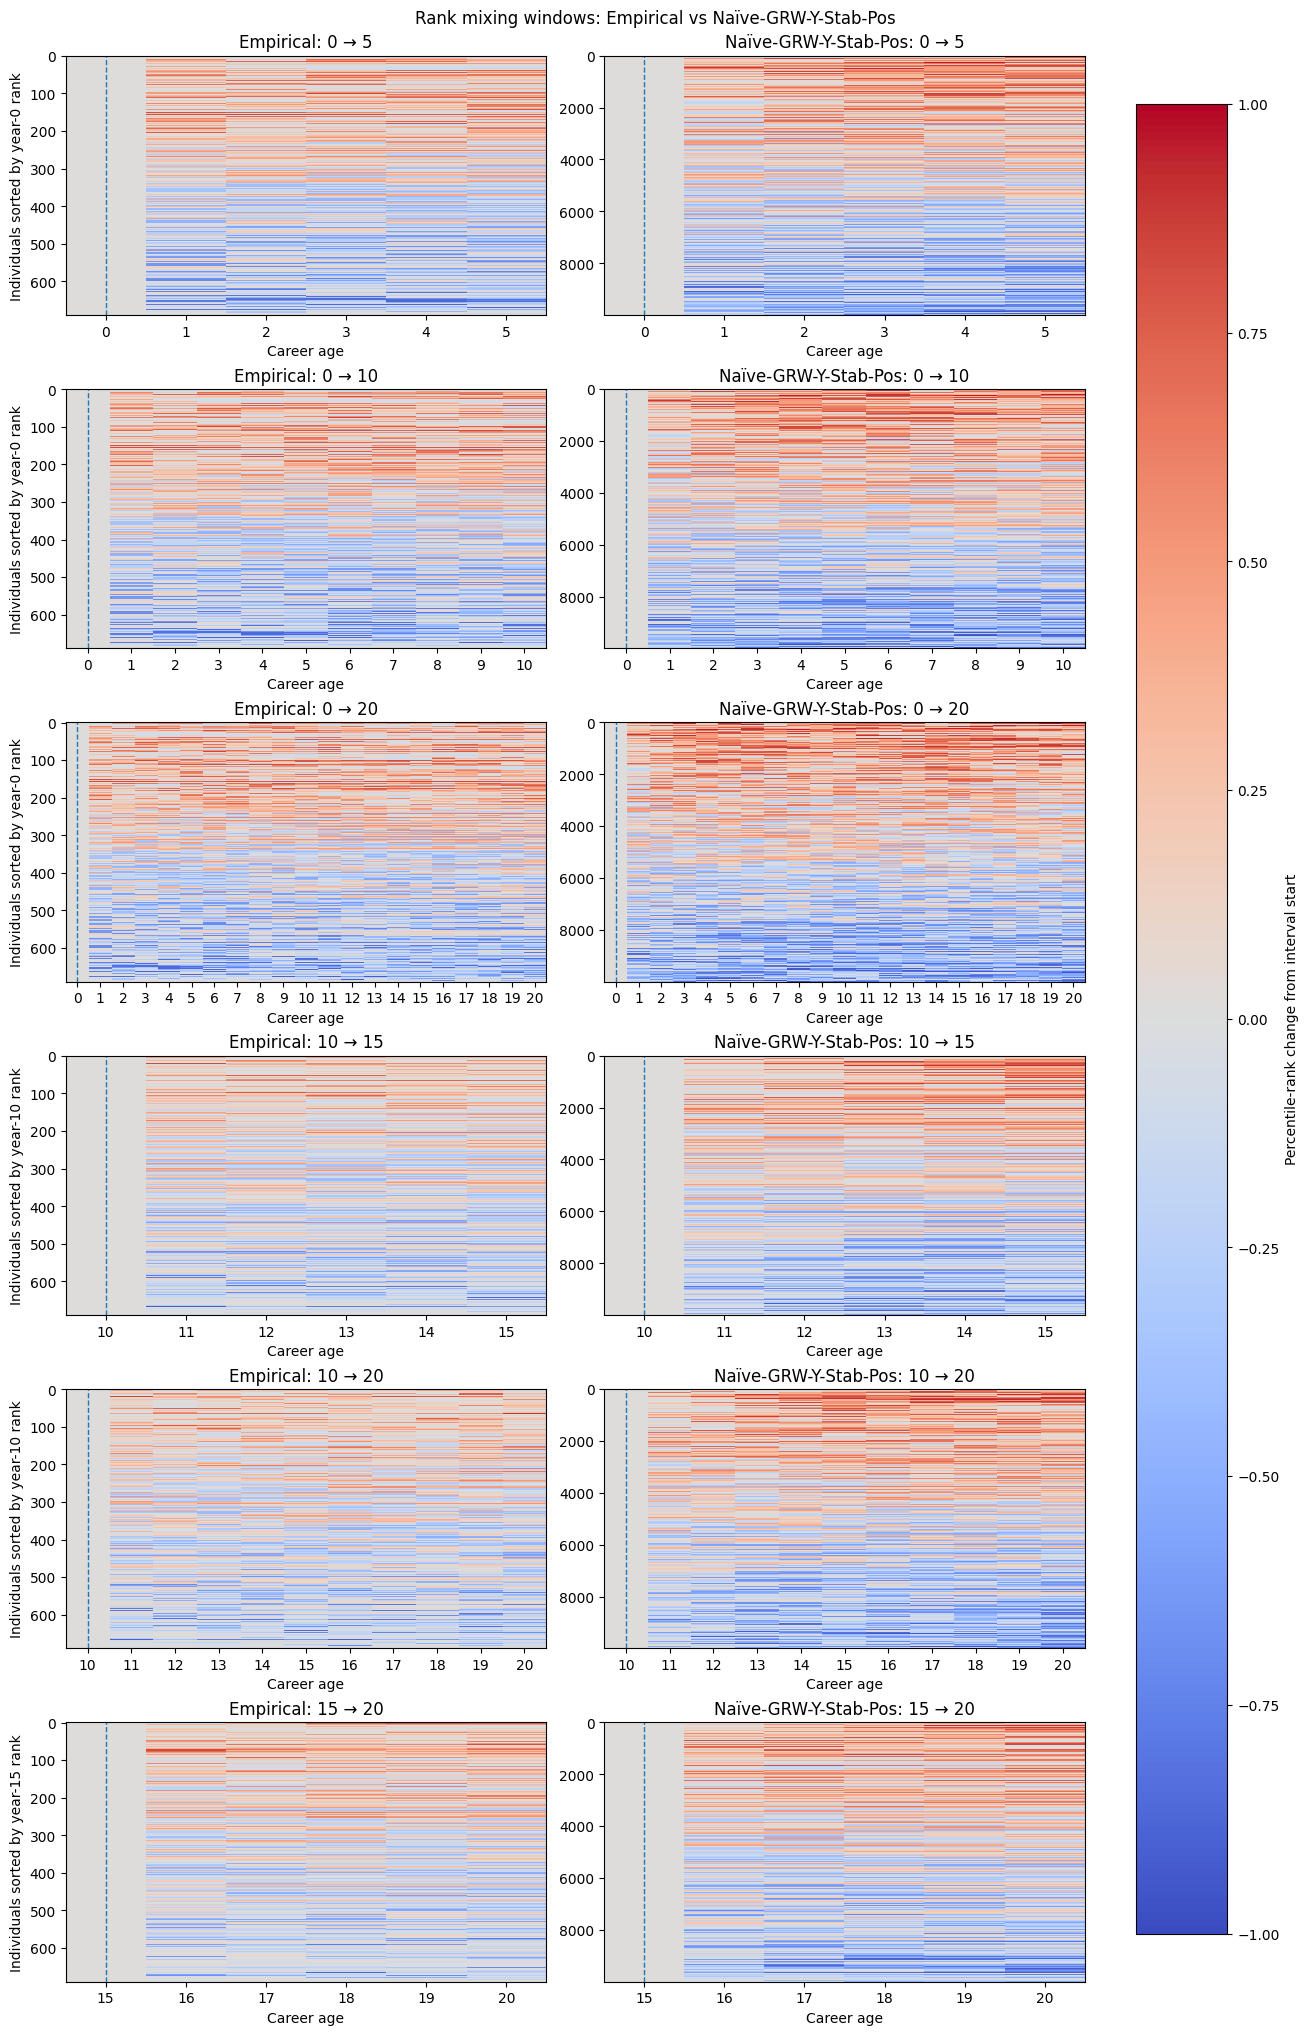

In [28]:

rank_windows = [(0, 5), (0, 10), (0, 20), (10, 15), (10, 20), (15, 20)]

def orient_trj(A):
    A = np.asarray(A)
    return A.T if A.shape[0] == Y + 1 else A

def rank_change_heatmap(mat, start, end):
    years = np.arange(start, end + 1)
    ranks = pd.DataFrame(mat[:, years]).rank(method="average", pct=True).to_numpy()
    delta = ranks - ranks[:, [0]]
    order = np.argsort(ranks[:, 0])
    return delta[order], years

emp_rank_mat = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj")
    .reindex(columns=np.arange(Y + 1))
    .dropna()
    .to_numpy()
)

sim_rank_mat = orient_trj(trajs)

fig, axes = plt.subplots(len(rank_windows), 2, figsize=(13, 20), constrained_layout=True)

vmin, vmax = -1.0, 1.0

for r, (start, end) in enumerate(rank_windows):
    for c, (label, mat) in enumerate([("Empirical", emp_rank_mat), (MODEL_NAME, sim_rank_mat)]):
        delta, years = rank_change_heatmap(mat, start, end)

        im = axes[r, c].imshow(delta, aspect="auto", cmap="coolwarm", vmin=vmin, vmax=vmax, interpolation="nearest")

        axes[r, c].set_title(f"{label}: {start} → {end}")
        axes[r, c].set_xlabel("Career age")
        axes[r, c].set_xticks(np.arange(len(years)))
        axes[r, c].set_xticklabels(years)
        axes[r, c].axvline(0, linestyle="--", linewidth=1)

        if c == 0:
            axes[r, c].set_ylabel(f"Individuals sorted by year-{start} rank")

cbar = fig.colorbar(im, ax=axes, shrink=0.95)
cbar.set_label("Percentile-rank change from interval start")

fig.suptitle(f"Rank mixing windows: Empirical vs {MODEL_NAME}", y=1.01)

plt.savefig(FIGURES / f"{MODEL_TAG}_rank_mixing_windows.png", dpi=300, bbox_inches="tight")
plt.show()